In [2]:
import requests
import pandas as pd
import folium

status_url = "https://gbfs.velobixi.com/gbfs/2-2/en/station_status.json"
status_data = requests.get(status_url).json()

stations = pd.json_normalize(status_data['data']['stations'])
stations.head()


,station_id,num_bikes_available,num_ebikes_available,vehicle_types_available,num_bikes_disabled,num_docks_available,num_docks_disabled,is_installed,is_renting,is_returning,last_reported,eightd_has_available_keys,is_charging
0,3,4,0,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",0,15,0,1,1,1,1772635669,False,False
1,15,15,0,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",0,0,0,1,1,1,1772632964,False,False
2,17,1,0,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",0,26,0,1,1,1,1772635506,False,False
3,19,22,0,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",1,4,0,1,1,1,1772635484,False,False
4,24,4,0,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",0,7,0,1,1,1,1772632369,False,False


In [3]:
stations.shape
stations.columns


Index(['station_id', 'num_bikes_available', 'num_ebikes_available',
       'vehicle_types_available', 'num_bikes_disabled', 'num_docks_available',
       'num_docks_disabled', 'is_installed', 'is_renting', 'is_returning',
       'last_reported', 'eightd_has_available_keys', 'is_charging'],
      dtype='object')

In [4]:
stations[['num_bikes_available','num_docks_available']].describe()


,num_bikes_available,num_docks_available
count,240.000000,240.000000
mean,9.412500,13.954167
std,6.799016,6.771988
min,0.000000,0.000000
25%,5.000000,9.000000
50%,8.000000,13.000000
75%,12.000000,17.000000
max,48.000000,39.000000


<Axes: >

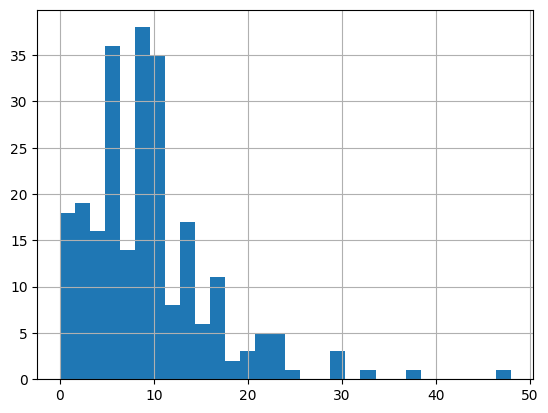

In [5]:
stations['num_bikes_available'].hist(bins=30)


In [6]:
stations.nlargest(10, 'num_bikes_available')[['station_id','num_bikes_available']]


,station_id,num_bikes_available
5,25,48
9,35,38
68,218,33
66,214,30
220,1058,30
37,111,29
99,388,24
19,68,23
29,95,23
65,210,23


In [7]:
stations['calculated_utilization'] = stations['num_bikes_available'] / (
    stations['num_bikes_available'] + stations['num_docks_available']
)
stations['calculated_utilization'].describe()


count    240.000000
mean       0.394168
std        0.212574
min        0.000000
25%        0.240558
50%        0.380952
75%        0.536401
max        1.000000
Name: calculated_utilization, dtype: float64

Checking Station Utilization Rate and Overlay on Map

In [8]:
# URLs
info_url   = "https://gbfs.velobixi.com/gbfs/2-2/en/station_information.json"

# Load JSON
status_data = requests.get(status_url).json()
info_data   = requests.get(info_url).json()

# Normalize into DataFrames
status_df = pd.json_normalize(status_data['data']['stations'])
info_df   = pd.json_normalize(info_data['data']['stations'])


In [9]:
stations_merged = pd.merge(info_df, status_df, on="station_id")
stations_merged.head()


,station_id,external_id,name,short_name,lat,lon,rental_methods,capacity,electric_bike_surcharge_waiver,is_charging_x,...,vehicle_types_available,num_bikes_disabled,num_docks_available,num_docks_disabled,is_installed,is_renting,is_returning,last_reported,eightd_has_available_keys,is_charging_y
0,3,0b0fe114-08f3-11e7-a1cb-3863bb33a4e4,Clark / Ontario,6003,45.510588,-73.566846,"[KEY, CREDITCARD]",19,False,False,...,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",0,15,0,1,1,1,1772635669,False,False
1,15,0b0ffa68-08f3-11e7-a1cb-3863bb33a4e4,Métro Berri-UQAM (St-Denis / de Maisonneuve),6015,45.514252,-73.561502,"[KEY, CREDITCARD]",15,False,False,...,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",0,0,0,1,1,1,1772632964,False,False
2,17,0b0ffd3a-08f3-11e7-a1cb-3863bb33a4e4,Marché St-Jacques (Atateken),6017,45.520666,-73.563915,"[KEY, CREDITCARD]",27,False,False,...,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",0,26,0,1,1,1,1772635506,False,False
3,19,0b100002-08f3-11e7-a1cb-3863bb33a4e4,Métro Sherbrooke (de Rigaud / Berri),6019,45.518143,-73.568004,"[KEY, CREDITCARD]",27,False,False,...,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",1,4,0,1,1,1,1772635484,False,False
4,24,0b1006f9-08f3-11e7-a1cb-3863bb33a4e4,Notre-Dame / St-Gabriel,6025,45.507118,-73.555049,"[KEY, CREDITCARD]",11,False,False,...,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",0,7,0,1,1,1,1772632369,False,False


In [10]:
stations_merged['capacity'] = stations_merged['capacity'].astype(int)
stations_merged['utilization'] = stations_merged['num_bikes_available'] / stations_merged['capacity']


In [11]:

# Center map on Montréal
m = folium.Map(location=[45.5017, -73.5673], zoom_start=12)

# Add stations
for _, row in stations_merged.iterrows():
    popup_text = f"""
    <b>{row['name']}</b><br>
    Bikes Available: {row['num_bikes_available']}<br>
    Docks Available: {row['num_docks_available']}<br>
    Utilization: {row['utilization']:.0%}
    """
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=6,
        color="green" if row['utilization'] < 0.5 else "red",
        fill=True,
        fill_opacity=0.7,
        popup=popup_text
    ).add_to(m)

m.save("bixi_map_utilization.html")


Cross Check between both APIs (station status and station capacity)

In [12]:
stations_merged['calculated_capacity'] = stations_merged['num_bikes_available'] + stations_merged['num_docks_available']
top_capacity = stations_merged.nlargest(10, 'calculated_capacity')[['station_id','name','calculated_capacity']]
print(top_capacity)


    station_id                                               name  \
5           25              de la Commune / Place Jacques-Cartier   
144        582                       Jeanne-Mance / René-Lévesque   
220       1058                             de la Commune / McGill   
148        608                              McTavish / Sherbrooke   
203        952            Métro Viau (Pierre-de-Coubertin / Viau)   
18          62              Métro Peel (de Maisonneuve / Stanley)   
99         388    Métro Pie-IX (Pierre-de-Coubertin / Desjardins)   
9           35                         de la Commune / St-Sulpice   
66         214  Parc Jeanne-Mance (monument sir George-Étienne...   
23          77                                  Peel / Notre-Dame   

     calculated_capacity  
5                     80  
144                   60  
220                   56  
148                   54  
203                   52  
18                    49  
99                    48  
9                     47

<Axes: >

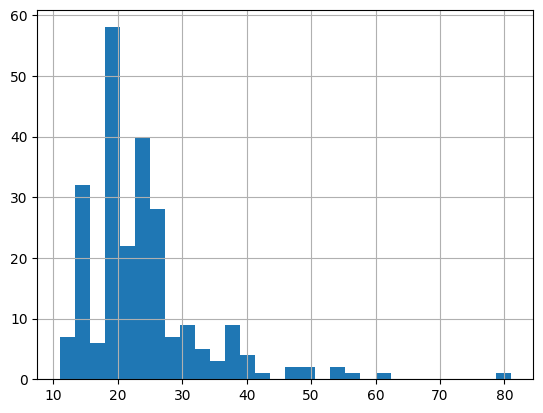

In [13]:
stations_merged['capacity'].hist(bins=30)


In [14]:
stations_merged[['name','capacity','calculated_capacity']].sort_values('capacity', ascending=False).head(20)


,name,capacity,calculated_capacity
5,de la Commune / Place Jacques-Cartier,81,80
144,Jeanne-Mance / René-Lévesque,61,60
220,de la Commune / McGill,56,56
203,Métro Viau (Pierre-de-Coubertin / Viau),55,52
148,McTavish / Sherbrooke,54,54
18,Métro Peel (de Maisonneuve / Stanley),49,49
99,Métro Pie-IX (Pierre-de-Coubertin / Desjardins),49,48
9,de la Commune / St-Sulpice,47,47
66,Parc Jeanne-Mance (monument sir George-Étienne...,47,47
23,Peel / Notre-Dame,43,43


In [15]:
stations_merged[['name','capacity','calculated_capacity']].sort_values('capacity', ascending=False).tail(0)


,name,capacity,calculated_capacity


In [16]:
stations_merged.head()

,station_id,external_id,name,short_name,lat,lon,rental_methods,capacity,electric_bike_surcharge_waiver,is_charging_x,...,num_docks_available,num_docks_disabled,is_installed,is_renting,is_returning,last_reported,eightd_has_available_keys,is_charging_y,utilization,calculated_capacity
0,3,0b0fe114-08f3-11e7-a1cb-3863bb33a4e4,Clark / Ontario,6003,45.510588,-73.566846,"[KEY, CREDITCARD]",19,False,False,...,15,0,1,1,1,1772635669,False,False,0.210526,19
1,15,0b0ffa68-08f3-11e7-a1cb-3863bb33a4e4,Métro Berri-UQAM (St-Denis / de Maisonneuve),6015,45.514252,-73.561502,"[KEY, CREDITCARD]",15,False,False,...,0,0,1,1,1,1772632964,False,False,1.000000,15
2,17,0b0ffd3a-08f3-11e7-a1cb-3863bb33a4e4,Marché St-Jacques (Atateken),6017,45.520666,-73.563915,"[KEY, CREDITCARD]",27,False,False,...,26,0,1,1,1,1772635506,False,False,0.037037,27
3,19,0b100002-08f3-11e7-a1cb-3863bb33a4e4,Métro Sherbrooke (de Rigaud / Berri),6019,45.518143,-73.568004,"[KEY, CREDITCARD]",27,False,False,...,4,0,1,1,1,1772635484,False,False,0.814815,26
4,24,0b1006f9-08f3-11e7-a1cb-3863bb33a4e4,Notre-Dame / St-Gabriel,6025,45.507118,-73.555049,"[KEY, CREDITCARD]",11,False,False,...,7,0,1,1,1,1772632369,False,False,0.363636,11


Discrepancy exists between the station status bikes available + docks available

To use station capacity data directly

In [17]:
for _, row in stations_merged.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=row['capacity'] / 10,  # scale marker size
        color="blue",
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['name']}<br>Total Capacity: {row['capacity']}"
    ).add_to(m)


In [18]:
top20_utilization = stations_merged.nlargest(20, 'utilization')[['station_id','name','capacity','num_bikes_available','num_docks_available','utilization']]
print(top20_utilization)

    station_id                                               name  capacity  \
1           15       Métro Berri-UQAM (St-Denis / de Maisonneuve)        15   
160        692                                 de Gaspé / Marmier        21   
88         347              Métro Mont-Royal (Place Gérald-Godin)        23   
65         210                            Duluth / de l'Esplanade        27   
68         218                              du Mont-Royal / Clark        39   
24          79   Métro Lucien-L'Allier (Lucien l'Allier / Argyle)        11   
3           19               Métro Sherbrooke (de Rigaud / Berri)        27   
101        390  Parc Hilda-Ramacière (de Bullion / Prince-Arthur)        27   
233       1141           Parc des Gorilles (Beaubien / St-Urbain)        21   
9           35                         de la Commune / St-Sulpice        47   
37         111                         de Maisonneuve / de Bleury        36   
114        438                            de Maisonn

In [19]:
bot10_utilization = stations_merged.nsmallest(10, 'utilization')[['station_id','name','capacity','num_bikes_available','num_docks_available','utilization']]
print(bot10_utilization)

    station_id                                    name  capacity  \
51         157               St-Hubert / du Mont-Royal        11   
56         169       du Mont-Royal / Christophe-Colomb        11   
61         206                      Boyer / Jean-Talon        15   
112        428  Métro de l'Église (Ross / de l'Église)        18   
123        489                   Lajeunesse / Villeray        15   
171        780                         Masson / Molson        19   
235       1146                 de Maisonneuve / Mackay        19   
2           17            Marché St-Jacques (Atateken)        27   
132        544                    Cartier / Marie-Anne        27   
46         141                  Émile-Duployé / Rachel        25   

     num_bikes_available  num_docks_available  utilization  
51                     0                   11     0.000000  
56                     0                   11     0.000000  
61                     0                   15     0.000000  
112    

In [20]:
stations_merged['find_discrepancy'] = (
    stations_merged['num_bikes_available'] 
    + stations_merged['num_ebikes_available'] 
    + stations_merged['num_docks_available'] 
    + stations_merged['num_docks_disabled']
   # + stations_merged['num_bikes_disabled']
)

discrepancies = stations_merged[
    stations_merged['capacity'] != stations_merged['find_discrepancy']
]

In [21]:
discrepancies['difference'] = discrepancies['capacity'] - discrepancies['find_discrepancy']
discrepancies[['name','capacity','find_discrepancy','difference']] \
    .sort_values('difference', ascending=False) \
    .head(20)

C:\Users\Daniel Loh\AppData\Local\Temp\ipykernel_24800\2049204711.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  discrepancies['difference'] = discrepancies['capacity'] - discrepancies['find_discrepancy']


,name,capacity,find_discrepancy,difference
203,Métro Viau (Pierre-de-Coubertin / Viau),55,52,3
41,Messier / Rachel,27,25,2
36,Métro Frontenac (Ontario / du Havre),23,21,2
165,Parc Labelle (LaSalle / Henri-Duhamel),19,17,2
204,Hamilton / Jolicoeur,15,13,2
13,Robert-Bourassa / St-Maurice,23,22,1
5,de la Commune / Place Jacques-Cartier,81,80,1
31,Frontenac / Ste-Catherine,19,18,1
38,Ontario / Poupart,19,18,1
44,Métro Fabre (Fabre / Jean-Talon),11,10,1


No discrepancy if consider number of bikes disabled

In [22]:
stations_merged[stations_merged['name'] == "de Maisonneuve / Fullum"][['num_bikes_available', 'num_ebikes_available', 'num_docks_available', 'num_docks_disabled', 'num_bikes_disabled']]

,num_bikes_available,num_ebikes_available,num_docks_available,num_docks_disabled,num_bikes_disabled
30,5,0,12,0,0


<Axes: >

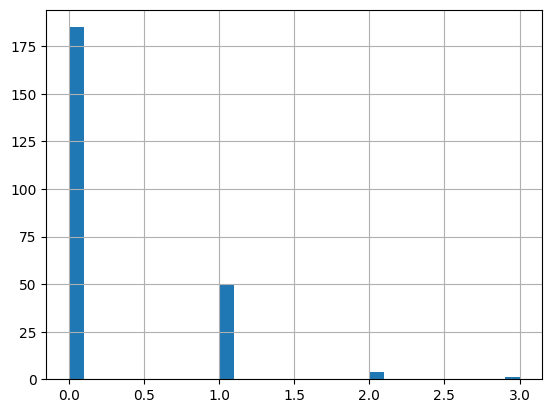

In [23]:
stations_merged['num_bikes_disabled'].hist(bins=30)


In [24]:
stations_merged[stations_merged['name'].str.upper() == "FULLUM / MARIE-ANNE"][['num_bikes_available', 'num_ebikes_available', 'num_docks_available', 'num_docks_disabled', 'num_bikes_disabled']]

,num_bikes_available,num_ebikes_available,num_docks_available,num_docks_disabled,num_bikes_disabled
131,6,0,20,0,0
